# EDA (Exploratory Data Analysis)

Understand the dataset and detect general problems or patterns 

## Index

- [EDA (Exploratory Data Analysis)](#EDA-Exploratory-Data-Analysis)
  - [Index](#Index)
  - [Loading libraries](#Loading-libraries)
  - [Data Loading](#Data-Loading)
  - [Initial Exploration](#Initial-Exploration)
    - [Exploration of Numerical Variables **(1 2 3)**](#Exploration-of-Numerical-Variables-1-2-3)
    - [Exploration of Non-Numerical Variables **(a b c)**](#Exploration-of-Non-Numerical-Variables-a-b-c)
    - [Exploration of Date Variables **(dd/mm/aaaa)**](#Exploration-of-Date-Variables-ddmmaaaa)
  - [Data exploration with Graphs](#Data-exploration-with-Graphs)
    - [Graphic Exploration of Numerical Variables **(1 2 3)**](#Graphic-Exploration-of-Numerical-Variables-1-2-3)
        - [Histogram of Variables](#Histogram-of-Variables)
        - [Q-Q Plots](#Q-Q-Plots)
        - [Box Plot](#Box-Plot)
    - [Graphic Exploration of Non-Numerical Variables **(a b c)**](#Graphic-Exploration-of-Non-Numerical-Variables-a-b-c)
        - [Simple bar chart](#Simple-bar-chart)
    - [Graphic Exploration of Date Variables **(dd/mm/aaaa)**](#Graphic-Exploration-of-Date-Variables-ddmmaaaa)
        - [Box Plot](#Box-Plot)




## Loading libraries

In [ ]:
# Data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Preprocess
from scipy import stats

# Configuración matplotlib
plt.style.use('ggstatistical_analysisplot')

# Paths
import sys
import os
sys.path.append(os.path.abspath('../scripts'))
from paths import Paths

# Scripts
from visualization_scripts import distribution_grapher, qq_grapher, boxplots_grapher
from eda_scripts import unique_values


## Data Loading

In [2]:
## Dowload DataSet:
# https://www.kaggle.com/code/markmedhat/weather-seattle/input

data = pd.read_csv(str(Paths.DATA_RAW)+"/seattle-weather.csv")
print(data.head(5))

         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain


## Initial Exploration

In [3]:
data.columns

Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather'], dtype='object')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


In [5]:
print(f"Duplicate records found: {data.duplicated().sum()}")  # Número de filas duplicadas

Duplicate records found: 0


### Exploration of Numerical Variables **(1 2 3)**

In [6]:
numerical_columns = ['precipitation', 'temp_max', 'temp_min', 'wind']
df_num = data[numerical_columns]

In [7]:
df_num.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


### Exploration of Non-Numerical Variables **(a b c)**

In [8]:
no_numerical_columns = ['weather']
df_no_num = data[no_numerical_columns]

In [9]:
df_no_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   weather  1461 non-null   object
dtypes: object(1)
memory usage: 11.5+ KB


In [10]:
uniqueval_df = unique_values(df_no_num)
pd.DataFrame(uniqueval_df[0])
print(pd.DataFrame(uniqueval_df[0]))

  Un_Value weather  Count
0             rain    641
1              sun    640
2              fog    101
3          drizzle     53
4             snow     26


### Exploration of Date Variables **(dd/mm/aaaa)**

In [11]:
data["date"] = pd.to_datetime(data["date"])
print(data["date"].describe())

count                   1461
mean     2013-12-31 00:00:00
min      2012-01-01 00:00:00
25%      2012-12-31 00:00:00
50%      2013-12-31 00:00:00
75%      2014-12-31 00:00:00
max      2015-12-31 00:00:00
Name: date, dtype: object


## Data exploration with Graphs

### Graphic Exploration of Numerical Variables **(1 2 3)**

#### Histogram of Variables
The histogram will show if the data somehow shows a tendency toward a specific value, and the normal function is the theoretical function that a distribution showing that pattern should follow.

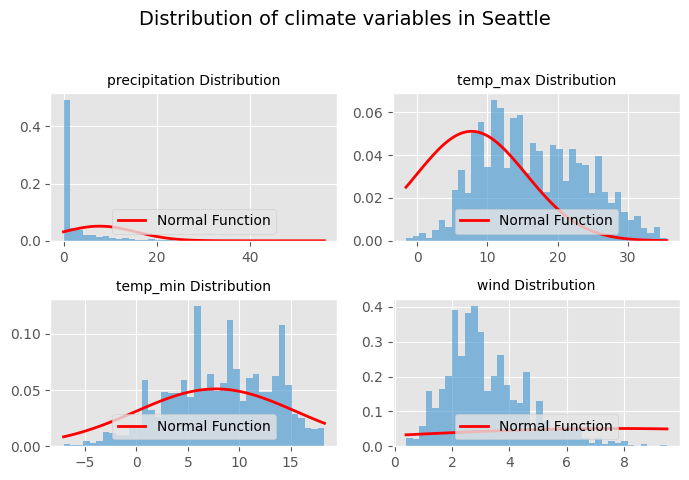

In [12]:
distribution_grapher(df_num, [2,2], [7,5],"Distribution of climate variables in Seattle")

#### Q-Q Plots
Another frequently used representation is theoretical quantile plots (Q-Q plots).

These plots compare the quantiles of the observed distribution with the theoretical quantiles of a normal distribution with the same mean and standard deviation as the data. The closer the data are to a normal distribution, the more closely the points are aligned with the line.

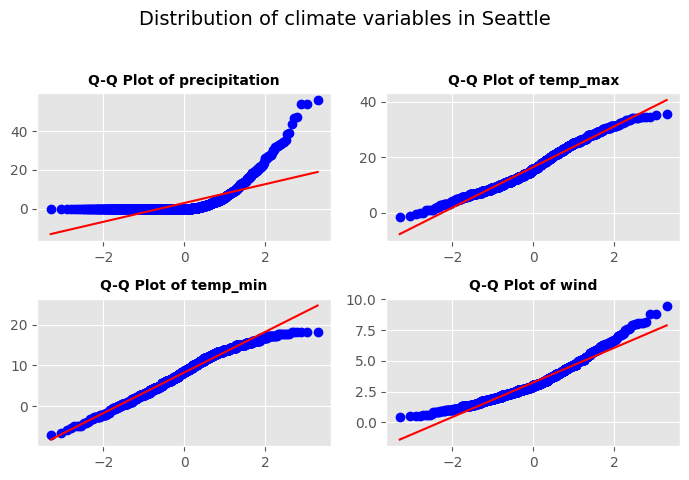

In [13]:
qq_grapher(df_num, [2,2], [7,5],"Distribution of climate variables in Seattle")

#### Box Plot
This type of plot helps visualize the distribution of data in a simple way. Depending on the values ​​on the Y axis, it may be convenient to graph them separately to clearly see the limits of the graph in each case.

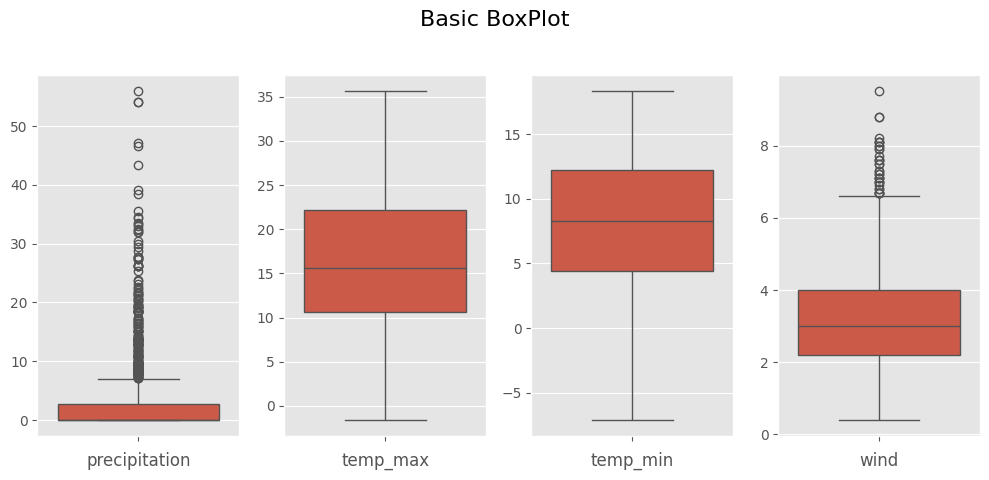

In [14]:
boxplots_grapher(df_num, [10,5], "Basic BoxPlot")

### Graphic Exploration of Non-Numerical Variables **(a b c)**

#### Simple bar chart
Helps to easily identify the differences between the number of data according to a classification

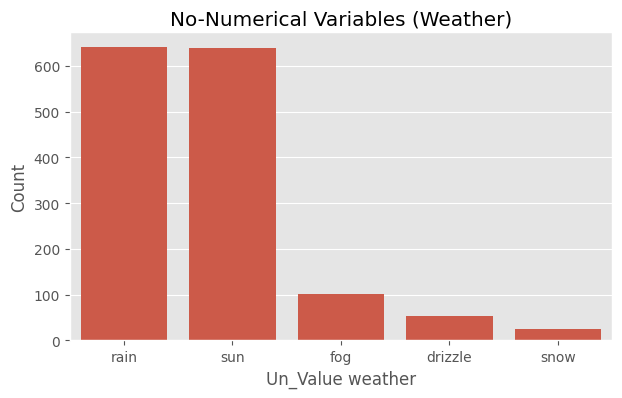

In [15]:
df_weather = pd.DataFrame(uniqueval_df[0])
fig, ax = plt.subplots(figsize = (7,4))
sns.barplot(data = df_weather, x = df_weather["Un_Value weather"], y = "Count")
ax.set_title("No-Numerical Variables (Weather)")
plt.show()

### Graphic Exploration of Date Variables **(dd/mm/aaaa)**

#### Box Plot

It helps to graphically view the distribution of dates, quickly visualizing if there are disparities in the date ranges, temporal biases, maximum and minimum range of available dates.

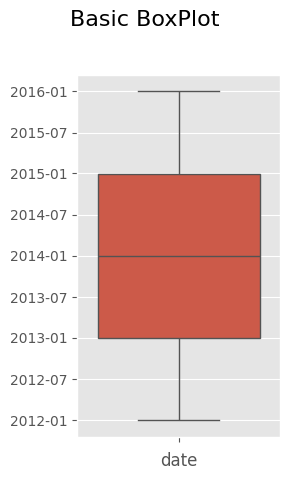

In [16]:
boxplots_grapher(data["date"].to_frame(), [3,5], "Basic BoxPlot")